# Analisis Hasil Eksperimen Feature Combination (no-fairness)

Input: `feature_combination_experiment_summary.csv`


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

INPUT_FILE = Path("feature_combination_experiment_summary.csv")
OUTPUT_DIR = Path("analysis_final_4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(INPUT_FILE, sep=None, engine="python")
df.columns = df.columns.str.replace("\ufeff", "", regex=False)

print("Jumlah baris, kolom:", df.shape)
df.head()

Jumlah baris, kolom: (84, 67)


,experiment_id,experiment_name,popularity_id,popularity_features,value_id,value_features,scenario,alpha,beta,gamma,...,mean_fairness@30,mean_f1@30,mean_tp@35,mean_fp@35,mean_fn@35,mean_precision@35,mean_recall@35,mean_ndcg@35,mean_fairness@35,mean_f1@35
0,1,E001_B1_countSold__G1_ratingAverage__balanced_...,B1_countSold,countSold,G1_ratingAverage,ratingAverage,balanced_no_fairness,0.34,0.33,0.33,...,0.695556,0.899629,25.2,4.8,0.0,0.84,1.0,0.936474,0.695556,0.899629
1,2,E002_B1_countSold__G1_ratingAverage__relevance...,B1_countSold,countSold,G1_ratingAverage,ratingAverage,relevance_dominant_no_fairness,0.50,0.25,0.25,...,0.695556,0.899629,25.2,4.8,0.0,0.84,1.0,0.935417,0.695556,0.899629
2,3,E003_B1_countSold__G1_ratingAverage__popularit...,B1_countSold,countSold,G1_ratingAverage,ratingAverage,popularity_dominant_no_fairness,0.25,0.50,0.25,...,0.695556,0.899629,25.2,4.8,0.0,0.84,1.0,0.930366,0.695556,0.899629
3,4,E004_B1_countSold__G1_ratingAverage__value_dom...,B1_countSold,countSold,G1_ratingAverage,ratingAverage,value_dominant_no_fairness,0.25,0.25,0.50,...,0.695556,0.899629,25.2,4.8,0.0,0.84,1.0,0.935794,0.695556,0.899629
4,5,E005_B1_countSold__G2_discountPercentage__bala...,B1_countSold,countSold,G2_discountPercentage,discountPercentage,balanced_no_fairness,0.34,0.33,0.33,...,0.695556,0.899629,25.2,4.8,0.0,0.84,1.0,0.931099,0.695556,0.899629


## Konfigurasi metrik dan K

In [2]:
METRICS   = ["precision", "recall", "ndcg", "f1"]
K_VALUES  = [5, 10, 15, 20, 25, 30, 35]

metric_cols = {
    m: [f"mean_{m}@{k}" for k in K_VALUES]
    for m in METRICS
}

# Warna tetap per metrik
METRIC_COLORS = {
    "precision": "#185FA5",
    "recall":    "#0F6E56",
    "ndcg":      "#854F0B",
    "f1":        "#534AB7",
}

# Warna bar: normal vs pemenang
BAR_NORMAL  = "#B4B2A9"   # abu netral
BAR_WINNER  = "#185FA5"   # biru tegas

print("Konfigurasi selesai.")

Konfigurasi selesai.


## Fungsi bantu

In [3]:
def make_avg_metric_columns(data):
    result = data.copy()
    for metric, cols in metric_cols.items():
        result[f"avg_{metric}_allK"] = result[cols].mean(axis=1)
    return result


def summarize_by_group(data, group_col):
    temp = make_avg_metric_columns(data)
    avg_cols = [f"avg_{m}_allK" for m in METRICS]
    summary = (
        temp.groupby(group_col, as_index=False)[avg_cols]
        .mean()
        .sort_values(group_col)
        .reset_index(drop=True)
    )
    return summary


def shorten_label(label, max_len=18):
    """Persingkat label panjang dengan singkatan yang mudah dibaca."""
    replacements = {
        "countSold":         "cSold",
        "countReview":       "cRev",
        "totalRating":       "tRat",
        "ratingAverage":     "rAvg",
        "discountPercentage":"disc%",
        "balanced_no_fairness":           "Balanced",
        "popularity_dominant_no_fairness":"Pop-Dom",
        "relevance_dominant_no_fairness": "Rel-Dom",
        "value_dominant_no_fairness":     "Val-Dom",
    }
    for long, short in replacements.items():
        label = label.replace(long, short)
    label = label.replace(" + ", "+")
    return label


def plot_grouped_bar_highlight(summary, group_col, title, output_name):
    """
    Plot grouped bar dengan highlight bar tertinggi untuk setiap metrik.
    """

    summary = summary.reset_index(drop=True).copy()

    avg_cols = [f"avg_{m}_allK" for m in METRICS]
    avg_cols = [col for col in avg_cols if col in summary.columns]

    metrics_plot = [
        col.replace("avg_", "").replace("_allK", "")
        for col in avg_cols
    ]

    labels_raw = summary[group_col].tolist()
    labels_short = [shorten_label(label) for label in labels_raw]

    n_groups = len(labels_short)
    n_metrics = len(metrics_plot)

    x = np.arange(n_groups)
    width = 0.18

    fig, ax = plt.subplots(figsize=(max(10, n_groups * 1.6), 6))

    for i, (metric, col) in enumerate(zip(metrics_plot, avg_cols)):
        values = summary[col].to_numpy(dtype=float)

        max_value = np.nanmax(values)

        is_winner = np.isclose(values, max_value, equal_nan=False)

        colors = [
            METRIC_COLORS[metric] if is_winner[j] else BAR_NORMAL
            for j in range(n_groups)
        ]

        edgecolors = [
            "black" if is_winner[j] else "none"
            for j in range(n_groups)
        ]

        linewidths = [
            1.5 if is_winner[j] else 0
            for j in range(n_groups)
        ]

        bars = ax.bar(
            x + (i - n_metrics / 2 + 0.5) * width,
            values,
            width,
            color=colors,
            edgecolor=edgecolors,
            linewidth=linewidths,
            alpha=0.9,
            label=metric.capitalize(),
            zorder=3,
        )

        for j, bar in enumerate(bars):
            if is_winner[j]:
                bar_x = bar.get_x() + bar.get_width() / 2
                bar_y = bar.get_height()

                ax.annotate(
                    "★",
                    xy=(bar_x, bar_y),
                    xytext=(bar_x, bar_y + 0.012),
                    ha="center",
                    fontsize=10,
                    color=METRIC_COLORS[metric],
                    fontweight="bold",
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels_short, rotation=45, ha="right", fontsize=10)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("Rata-rata metrik semua K", fontsize=10)

    all_values = summary[avg_cols].to_numpy(dtype=float)
    min_val = np.nanmin(all_values)
    max_val = np.nanmax(all_values)

    ax.set_ylim(min_val - 0.02, max_val + 0.08)

    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    handles = [
        mpatches.Patch(color=METRIC_COLORS[m], label=m.capitalize())
        for m in metrics_plot
    ]

    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9
    )

    plt.tight_layout()

    output_path = OUTPUT_DIR / output_name
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Plot disimpan ke:", output_path)

## 1. popularity_features


,popularity_features,avg_precision_allK,avg_recall_allK,avg_ndcg_allK,avg_f1_allK
0,countReview,0.871767,0.665473,0.887557,0.698578
1,countReview + totalRating,0.871466,0.665552,0.886533,0.698548
2,countSold,0.870169,0.665405,0.888835,0.698067
3,countSold + countReview,0.871484,0.665680,0.887152,0.698585
4,countSold + countReview + totalRating,0.871857,0.665863,0.887471,0.698850
5,countSold + totalRating,0.872026,0.666099,0.888840,0.699025
6,totalRating,0.872638,0.666089,0.888152,0.699266


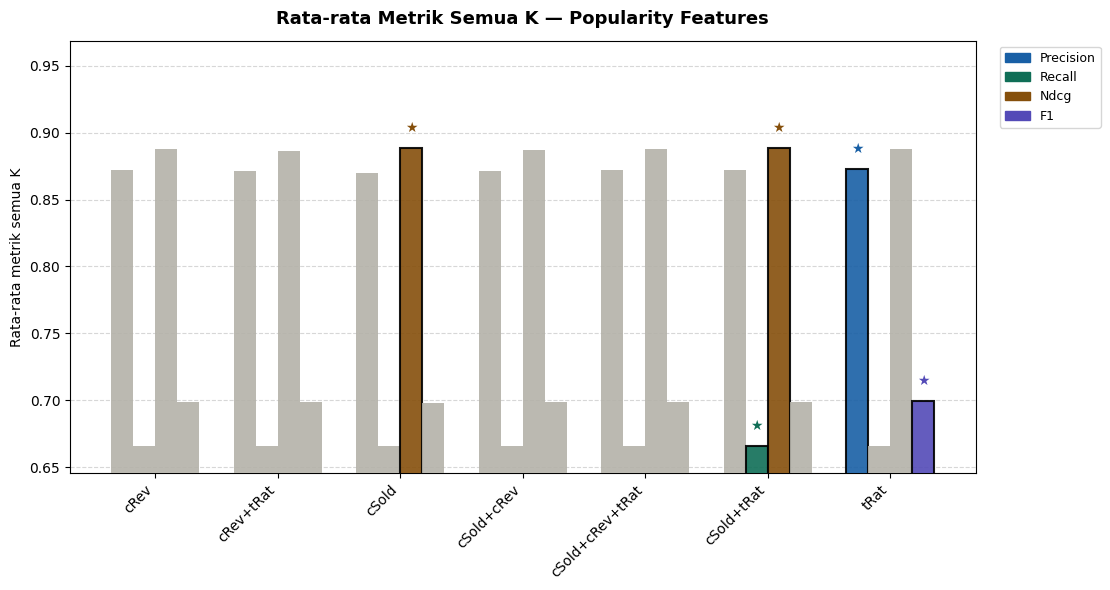

Plot disimpan ke: analysis_final_4_outputs\01_popularity_summary_avg_metrics_allK.png


In [4]:
popularity_summary = summarize_by_group(df, "popularity_features")
popularity_summary.to_csv(OUTPUT_DIR / "01_popularity_summary_avg_metrics_allK.csv", index=False)
display(popularity_summary)

plot_grouped_bar_highlight(
    popularity_summary,
    group_col="popularity_features",
    title="Rata-rata Metrik Semua K — Popularity Features",
    output_name="01_popularity_summary_avg_metrics_allK.png",
)

### perbandingan cSold+tRat vs trat:

- cSold+tRat unggul di recall (+0.000014) dan ndcg (+0.000877)
- tRat unggul di precision (+0.000856) dan f1 (+0.000337)

## 2. value_features


,value_features,avg_precision_allK,avg_recall_allK,avg_ndcg_allK,avg_f1_allK
0,discountPercentage,0.873130,0.666663,0.886577,0.699708
1,ratingAverage,0.868321,0.664328,0.888396,0.696863
2,ratingAverage + discountPercentage,0.873438,0.666220,0.888401,0.699538


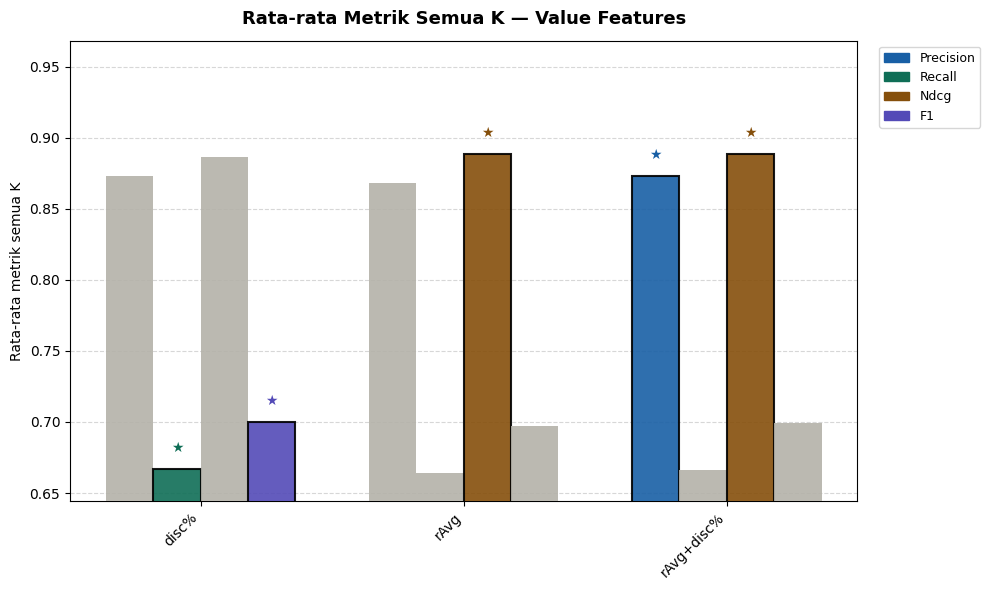

Plot disimpan ke: analysis_final_4_outputs\02_value_summary_avg_metrics_allK.png


In [5]:
value_summary = summarize_by_group(df, "value_features")
value_summary.to_csv(OUTPUT_DIR / "02_value_summary_avg_metrics_allK.csv", index=False)
display(value_summary)

plot_grouped_bar_highlight(
    value_summary,
    group_col="value_features",
    title="Rata-rata Metrik Semua K — Value Features",
    output_name="02_value_summary_avg_metrics_allK.png",
)

### perbandingan disc% vs rAvg+disc%:
- disc% unggul di recall (+0.00062) dan f1 (+0.000238)
- rAvg+disc% unggul di precision (+0.00043) dan ndcg (+0.001871)

## 3. Visualisasi Skenario hybrid


,scenario,avg_precision_allK,avg_recall_allK,avg_ndcg_allK,avg_f1_allK
0,balanced_no_fairness,0.872435,0.665720,0.889231,0.698839
1,popularity_dominant_no_fairness,0.875243,0.667232,0.884772,0.700773
2,relevance_dominant_no_fairness,0.868692,0.665428,0.892031,0.697757
3,value_dominant_no_fairness,0.870148,0.664568,0.885131,0.697442


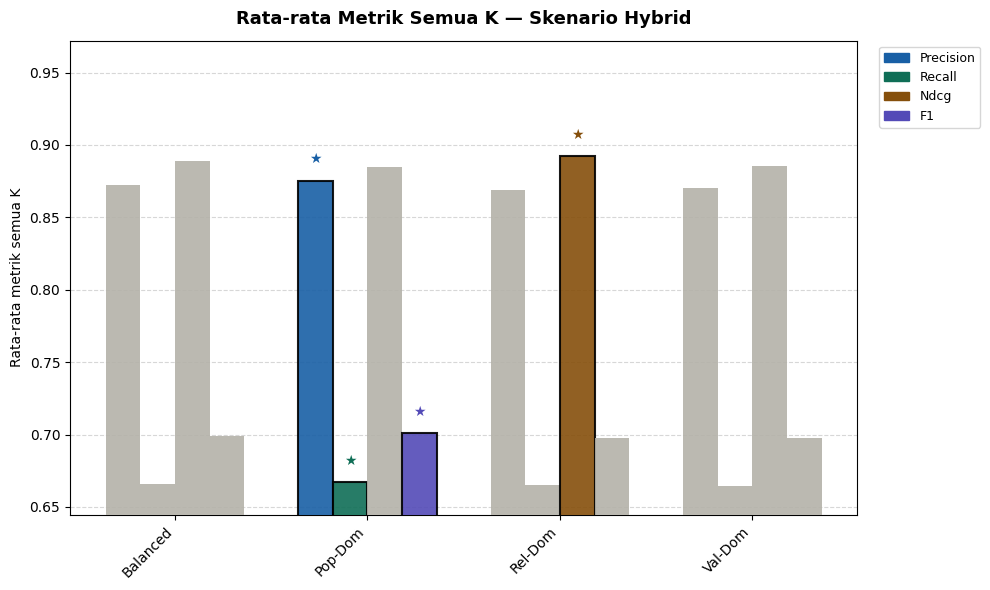

Plot disimpan ke: analysis_final_4_outputs\03_scenario_summary_avg_metrics_allK.png


In [6]:
scenario_summary = summarize_by_group(df, "scenario")
scenario_summary.to_csv(OUTPUT_DIR / "03_scenario_summary_avg_metrics_allK.csv", index=False)
display(scenario_summary)

plot_grouped_bar_highlight(
    scenario_summary,
    group_col="scenario",
    title="Rata-rata Metrik Semua K — Skenario Hybrid",
    output_name="03_scenario_summary_avg_metrics_allK.png",
)

popularity_dominant hanya kurang unggul pada metrik ndcg dari relevance_dominant (-0.008458)

## 4. Visualisasi Nilai K 


In [7]:
k_summary_rows = []
for k in K_VALUES:
    row = {"K": k}
    for m in METRICS:
        col = f"mean_{m}@{k}"
        row[f"avg_{m}"] = df[col].mean()
    k_summary_rows.append(row)

k_summary = pd.DataFrame(k_summary_rows)
k_summary.to_csv(OUTPUT_DIR / "04_k_summary_avg_all_metrics.csv", index=False)
display(k_summary)

,K,avg_precision,avg_recall,avg_ndcg,avg_f1
0,5,0.923492,0.193678,0.855763,0.316174
1,10,0.903016,0.375702,0.861099,0.521319
2,15,0.882963,0.545147,0.864497,0.661328
3,20,0.859841,0.693566,0.871676,0.754475
4,25,0.852095,0.852067,0.897295,0.838367
5,30,0.840000,1.000000,0.932104,0.899629
6,35,0.840000,1.000000,0.932104,0.899629


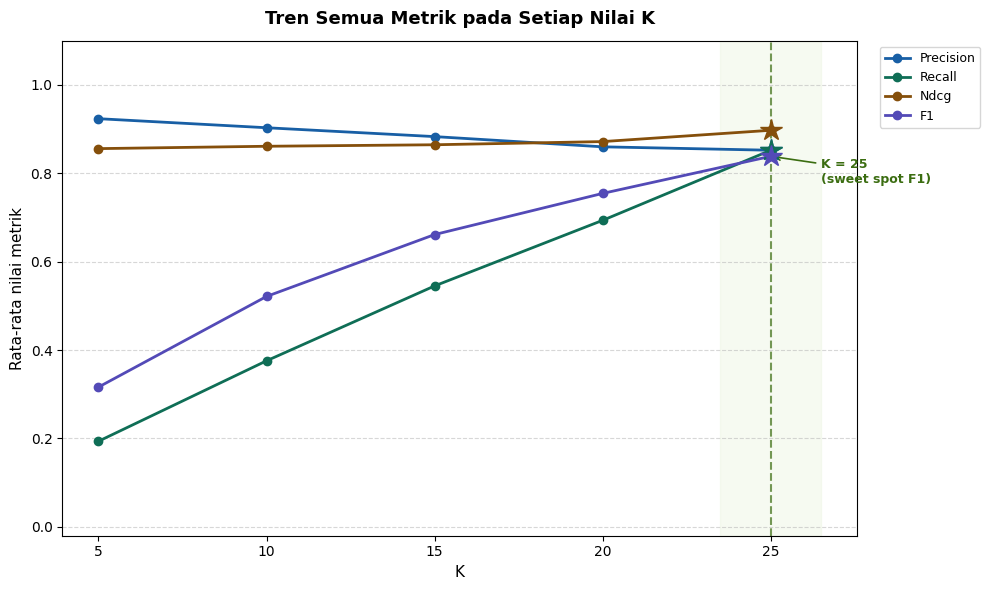

Plot disimpan ke: analysis_final_4_outputs\04_k_avg_all_metrics_linechart.png


In [8]:
# ── LINE CHART untuk nilai K ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

plot_metric_cols = [f"avg_{m}" for m in METRICS]
ks = k_summary["K"].tolist()

# Tentukan K terbaik berdasarkan F1
best_k_idx = k_summary["avg_f1"].idxmax()
best_k_val = k_summary.loc[best_k_idx, "K"]

for m, col in zip(METRICS, plot_metric_cols):
    values = k_summary[col].tolist()
    ax.plot(ks, values,
            marker="o", linewidth=2, markersize=6,
            color=METRIC_COLORS[m], label=m.capitalize(), zorder=3)

    # Tandai titik terbaik (K=best_k_val) dengan marker besar
    ax.plot(best_k_val, k_summary.loc[best_k_idx, col],
            marker="*", markersize=16,
            color=METRIC_COLORS[m], zorder=5)

# Garis vertikal dan shading area K terbaik
ax.axvline(best_k_val, color="#3B6D11", linewidth=1.5,
            linestyle="--", alpha=0.7, zorder=2)
ax.axvspan(best_k_val - 1.5, best_k_val + 1.5,
            color="#EAF3DE", alpha=0.4, zorder=0)

# Anotasi K terbaik
ax.annotate(
    f"K = {best_k_val}\n(sweet spot F1)",
    xy=(best_k_val, k_summary["avg_f1"].max()),
    xytext=(best_k_val + 1.5, k_summary["avg_f1"].max() - 0.06),
    arrowprops=dict(arrowstyle="->", color="#3B6D11", lw=1.2),
    fontsize=9, color="#3B6D11", fontweight="bold",
)

ax.set_title("Tren Semua Metrik pada Setiap Nilai K", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("K", fontsize=11)
ax.set_ylabel("Rata-rata nilai metrik", fontsize=11)
ax.set_xticks(K_VALUES)
ax.set_ylim(-0.02, 1.10)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)

plt.tight_layout()
output_path = OUTPUT_DIR / "04_k_avg_all_metrics_linechart.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print("Plot disimpan ke:", output_path)

- K=5  → precision paling tinggi, tapi recall dan F1 masih rendah
- K=10 → precision masih tinggi, NDCG stabil, F1 mulai naik
- K=15 → recall dan F1 naik, tapi precision mulai turun
- K=20 → lebih seimbang, recall dan F1 lebih baik
- K=25 → mendekati judged pool, mulai rawan bias